# Import Libaries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords #import irrelevant words to remove
from nltk.stem.porter import PorterStemmer #stemming the review -> only root of the word to convey meaning
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from imblearn.over_sampling import SMOTE

# Load Dataset

In [3]:
dataset = pd.read_csv("mbti_1.csv")

# Feature Engineering:
Let's add categories for each trait
* I = 1 E = 0
* N = 1 S = 0
* T = 1 F = 0
* P = 1 J = 0

In [4]:
dataset["I"] = 0
for i in range(dataset.shape[0]):
    if dataset.loc[i,"type"].find("I") != -1:
        dataset.loc[i,"I"] = 1
dataset["N"] = 0
for i in range(dataset.shape[0]):
    if dataset.loc[i,"type"].find("N") != -1:
        dataset.loc[i,"N"] = 1
dataset["T"] = 0
for i in range(dataset.shape[0]):
    if dataset.loc[i,"type"].find("T") != -1:
        dataset.loc[i,"T"] = 1
dataset["P"] = 0
for i in range(dataset.shape[0]):
    if dataset.loc[i,"type"].find("P") != -1:
        dataset.loc[i,"P"] = 1

Let's print the first 5 rows

In [5]:
dataset.head()

,type,posts,I,N,T,P
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,1,1,0,0
1,ENTP,'I'm finding the lack of me in these posts ver...,0,1,1,1
2,INTP,'Good one _____ https://www.youtube.com/wat...,1,1,1,1
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",1,1,1,0
4,ENTJ,'You're fired.|||That's another silly misconce...,0,1,1,0


# Distribution of MBTI's.

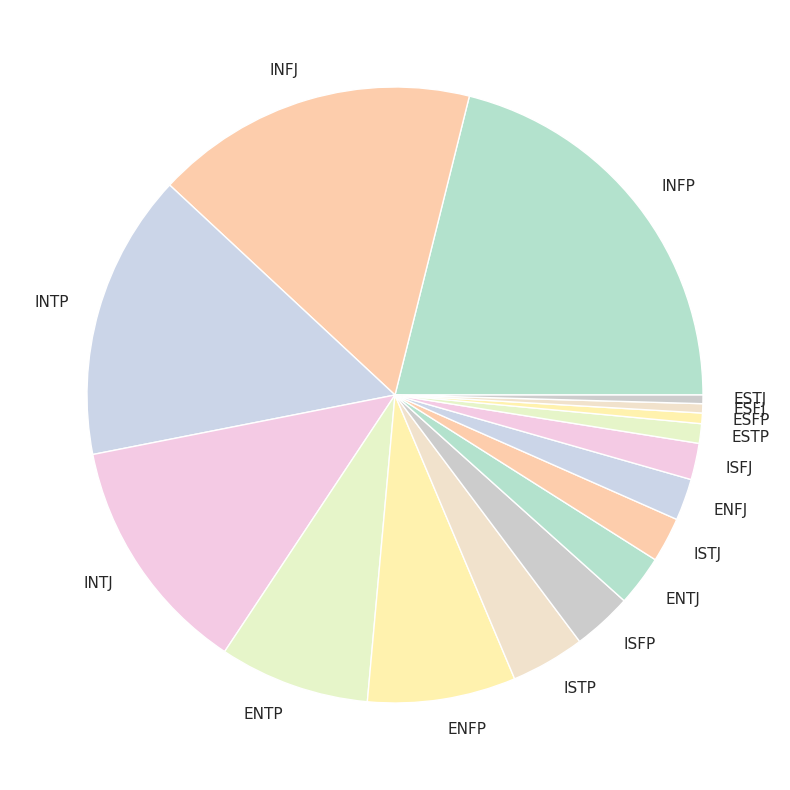

In [6]:
mbti_dict = dataset['type'].value_counts().to_dict()
mbti = list(mbti_dict.keys())
vals = list(mbti_dict.values())

#Plot
sns.set_theme()
fig, ax = plt.subplots(1,1,figsize = (10,10))
plt.pie(vals, labels = mbti, colors = plt.cm.Pastel2.colors)
plt.show()

# Distribution by trait

In [7]:
print(dataset["I"].value_counts())
print(dataset["N"].value_counts())
print(dataset["T"].value_counts())
print(dataset["P"].value_counts())

I
1    6676
0    1999
Name: count, dtype: int64
N
1    7478
0    1197
Name: count, dtype: int64
T
0    4694
1    3981
Name: count, dtype: int64
P
1    5241
0    3434
Name: count, dtype: int64


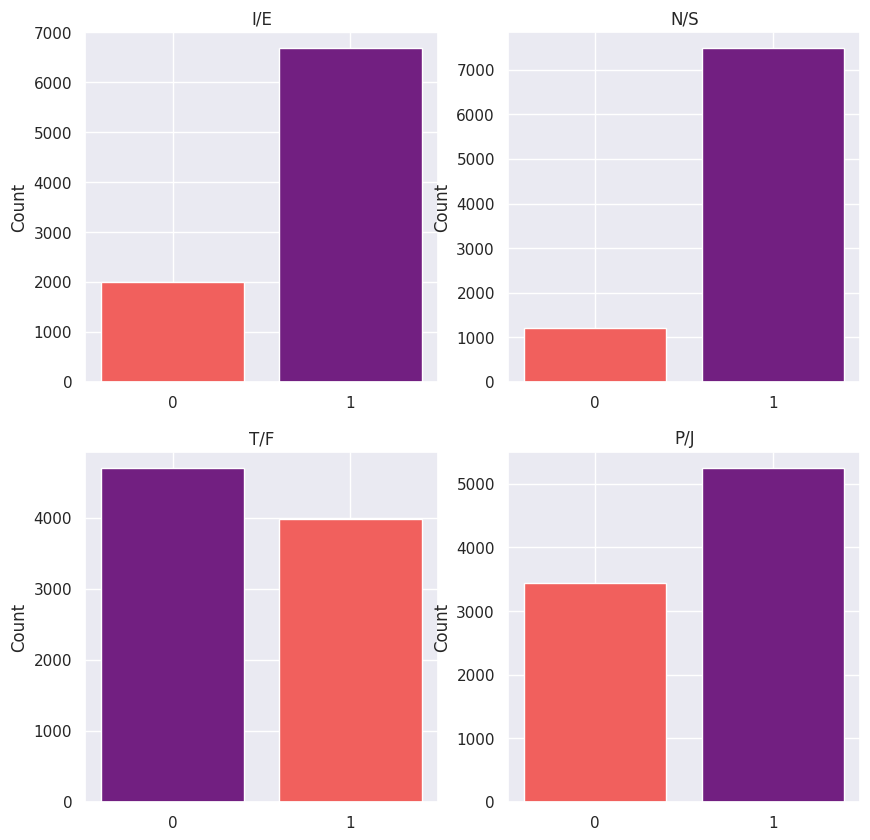

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))  
colors = sns.color_palette("magma", n_colors=2) 
def bar_plot(colors, ax, title, col):
    ax.bar(x = dataset[col].value_counts().index,
           height=dataset[col].value_counts().values,
           color=colors,
           tick_label = dataset[col].value_counts().index)
    ax.set_title(title)
    ax.set_ylabel("Count")
bar_plot(colors, axs[0][0], "I/E", "I" )
bar_plot(colors, axs[0][1], "N/S", "N" )
bar_plot(colors, axs[1][0], "T/F", "T") 
bar_plot(colors, axs[1][1], "P/J", "P") 

# **Insights:** 
* INFP's, INFJ's, and INTP's and INTJ's make up the majority of our dataset out of ALL the 16
* There may be bias in our machine learning model towards intuition and introversion, requiring us to oversample the minority via the SMOTE technique

# Natural Language Processing and Bag of words model Steps:
* Remove URL's
* Remove Stopwords and mentions of MBTI
* Convert all of the words into their stemmed form
* Create bag of words model

In [9]:
#Instantiate PorterStemmer to preserve only the stems 
ps = PorterStemmer()

#Remove the not keyword from the stopwords list and add the MBTI's to it, so we remove mentions of MBTI in the text.
all_stopwords = stopwords.words("english")
all_stopwords.remove("not")
mbti_types = ["intj", "infj", "entp", "enfp", "intp", "istp", "entj", "estj", 
              "isfp", "infp", "enfj", "esfj", "istj", "isfj", "esfp", "estp"]
all_stopwords.extend(mbti_types)


#Functions for preprocessing
def remove_urls(text):
    text = text.replace(" ", " ")
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
    
def preprocess_text(phrase):
    no_url_phrase = remove_urls(phrase)
    phrase = re.sub('[^a-zA-Z]', ' ',no_url_phrase)
    phrase = phrase.lower().split()
    phrase = [word for word in phrase if not word in (all_stopwords)]
    phrase = " ".join(phrase)
    return phrase

Apply function

In [10]:
dataset["modified_post"] = dataset["posts"].apply(preprocess_text)
corpus = dataset["modified_post"]
ie = dataset["I"]
ns = dataset["N"]
tf = dataset["T"]
pj = dataset["P"]

Contrast

In [11]:
dataset["posts"][0]

"'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8   http://www.youtube.com/watch?v=u8ejam5DP3E  On repeat for most of today.|||May the PerC Experience immerse you.|||The last thing my INFJ friend posted on his facebook before committing suicide the next day. Rest in peace~   http://vimeo.com/22842206|||Hello ENFJ7. Sorry to hear of your distress. It's only natural for a relationship to not be perfection all the time in every moment of existence. Try to figure the hard times as times of growth, as...|||84389  84390  http://wallpaperpassion.com/upload/23700/friendship-boy-and-girl-wallpaper.jpg  http://assets.dornob.com/wp-content/uploads/2010/04/round-home-design.jpg ...

In [12]:
dataset["modified_post"][0]

'moments sportscenter not top ten plays pranks life changing experience life repeat today may perc experience immerse last thing friend posted facebook committing suicide next day rest peace sorry hear distress natural relationship not perfection time every moment existence try figure hard times times growth welcome stuff game set match prozac wellbrutin least thirty minutes moving legs mean moving sitting desk chair weed moderation maybe try edibles healthier alternative basically come three items determined type whichever types want would likely use given types cognitive functions whatnot left things moderation sims indeed video game good one note good one somewhat subjective not completely promoting death given sim dear favorite video games growing current favorite video games cool appears late sad someone everyone wait thought confidence good thing cherish time solitude b c revel within inner world whereas time workin enjoy time worry people always around yo ladies complimentary pe

# **Bag of words Model**

In [13]:
cv = CountVectorizer(max_features=3000)
corpus = cv.fit_transform(corpus).toarray()

# **Define predict personality function**

In [14]:
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [15]:
def predict_personality(target, lr):
    #Split training and test set
    X_train, X_test, y_train, y_test = train_test_split(corpus, target,test_size=0.2, random_state= 42)    
    print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1))) 
    print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0))) 
    #Instantiate SMOTE variable
    sm = SMOTE(random_state=42)
    X_train, y_train = sm.fit_resample(X_train,y_train)
    print("After OverSampling, counts of label '1': {}".format(sum(y_train == 1))) 
    print("After OverSampling, counts of label '0': {} \n".format(sum(y_train == 0))) 

    #Train Classifier     
    lr.fit(X_train,y_train)
    y_pred = lr.predict(X_train)
    print("Training Set accuracy: ", accuracy_score(y_pred, y_train))
    y_pred = lr.predict(X_test)
    print("Test set accuracy: ", accuracy_score(y_pred, y_test))
    return confusion_matrix(y_true = y_test, y_pred = y_pred)/len(y_test)

Run code

Trait I/E

Before OverSampling, counts of label '1': 5323
Before OverSampling, counts of label '0': 1617 

After OverSampling, counts of label '1': 5323
After OverSampling, counts of label '0': 5323 



/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Set accuracy:  0.9322750328761976
Test set accuracy:  0.7706051873198847


Trait N/S

Before OverSampling, counts of label '1': 5989
Before OverSampling, counts of label '0': 951 

After OverSampling, counts of label '1': 5989
After OverSampling, counts of label '0': 5989 



/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Set accuracy:  0.9609283686759058
Test set accuracy:  0.837463976945245


Trait T/F

Before OverSampling, counts of label '1': 3183
Before OverSampling, counts of label '0': 3757 

After OverSampling, counts of label '1': 3757
After OverSampling, counts of label '0': 3757 



/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Set accuracy:  0.9200159701889805
Test set accuracy:  0.7706051873198847


Trait P/J

Before OverSampling, counts of label '1': 4175
Before OverSampling, counts of label '0': 2765 

After OverSampling, counts of label '1': 4175
After OverSampling, counts of label '0': 4175 



/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Set accuracy:  0.8770059880239521
Test set accuracy:  0.6870317002881844




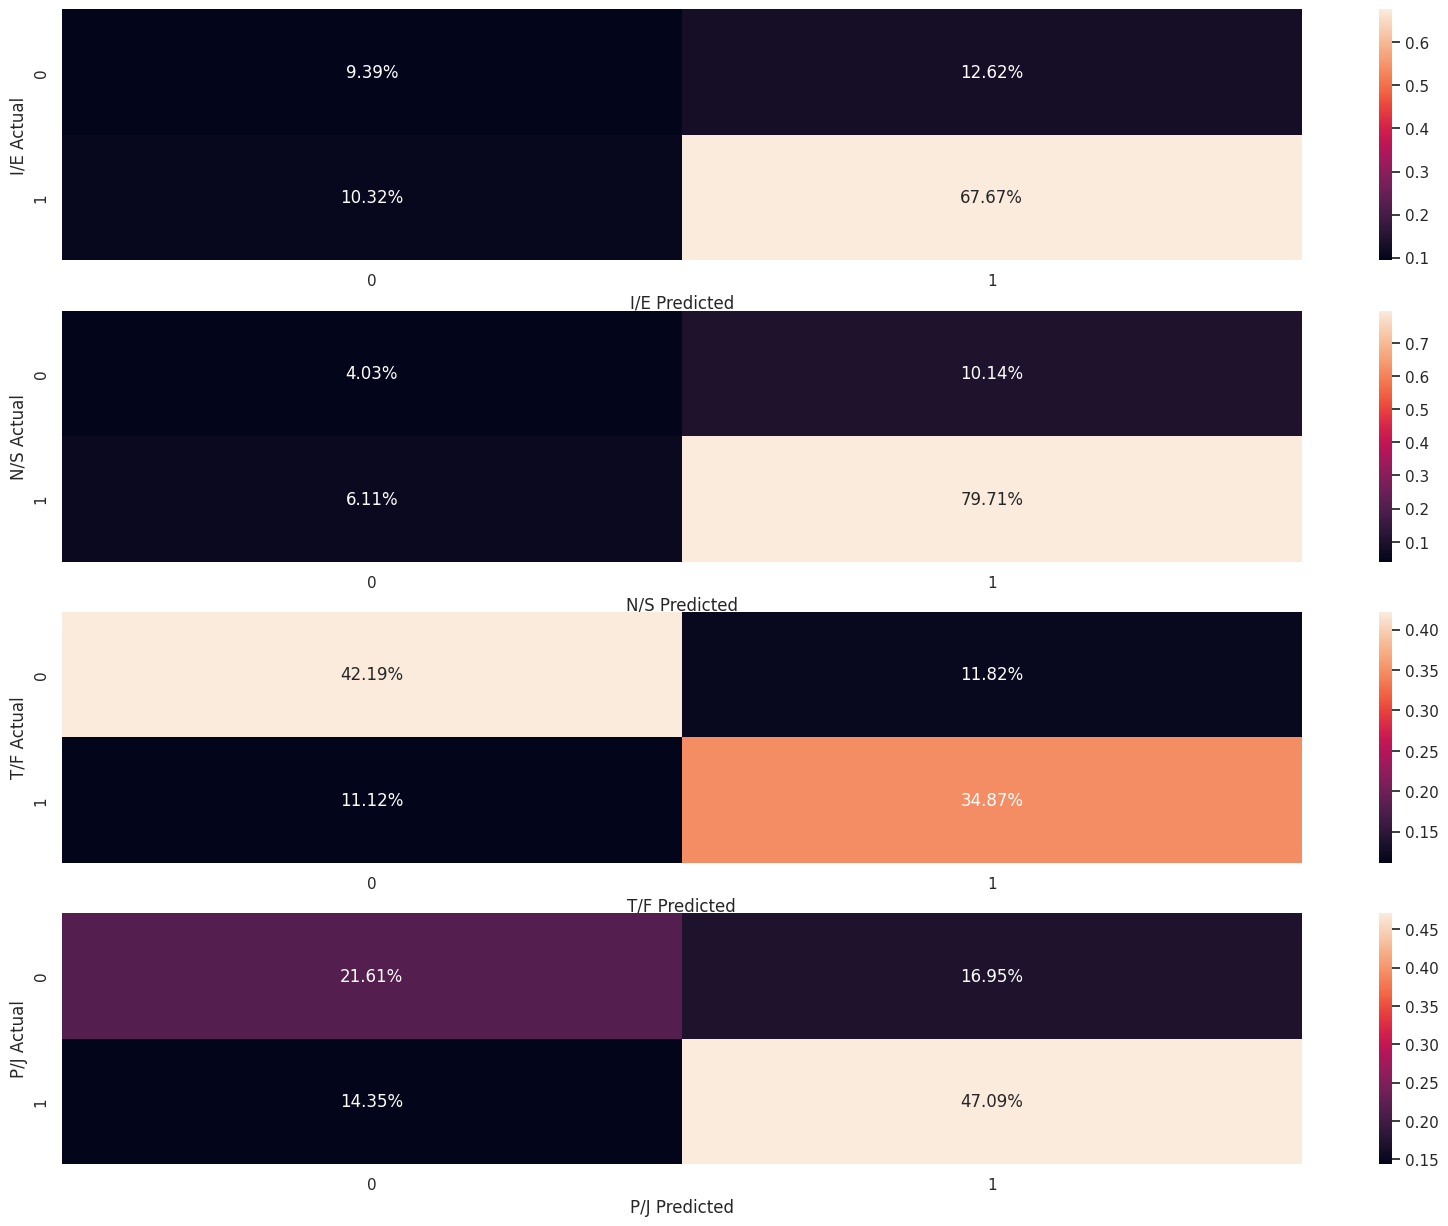

In [16]:
#Plot set-up
f, axs = plt.subplots(4,1, figsize = (20,15))
#Store trait values in a set
sets = {"I/E":ie, "N/S":ns, "T/F":tf, "P/J": pj}

i = 0
for name, set in sets.items():
    print("Trait {}\n".format(name))
    mtrx_map = sns.heatmap(predict_personality(set, LogisticRegression(solver = "saga")), ax=axs[i], annot = True, fmt='.2%')
    mtrx_map.set_xlabel(name + " Predicted")
    mtrx_map.set_ylabel(name + " Actual")
    print("\n")
    i+=1

# Word Clouds by MBTI:

In [17]:
data_subset = dataset[["type", "modified_post"]]

In [18]:
data_subset.head()

,type,modified_post
0,INFJ,moments sportscenter not top ten plays pranks ...
1,ENTP,finding lack posts alarming sex boring positio...
2,INTP,good one course say know blessing curse absolu...
3,INTJ,dear enjoyed conversation day esoteric gabbing...
4,ENTJ,fired another silly misconception approaching ...


In [19]:
def word_cloud(mbti):
    mbti_list = data_subset[data_subset["type"] == mbti]
    mbti_texts = mbti_list["modified_post"].sum()
        
    wordcloud = WordCloud(max_words= 250, background_color="white").generate(mbti_texts)

    #Plot
    fig, axs = plt.subplots(1,1, figsize = (10,10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(mbti)
    plt.show()

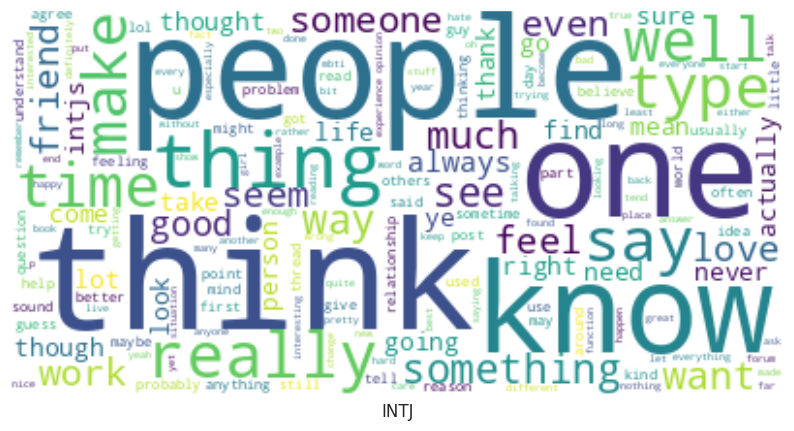

In [20]:
word_cloud("INTJ")

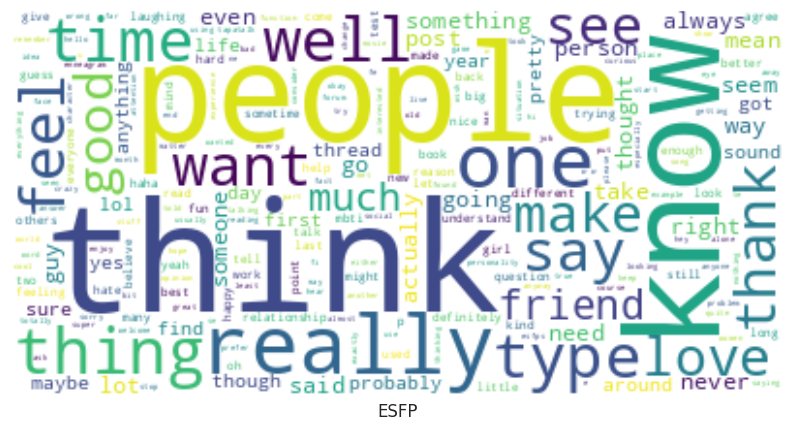

In [21]:
word_cloud("ESFP")

In [22]:
def word_cloud_by_trait(trait, bool_val, data):
    trait_obs = data[data[trait] == bool_val]
    trait_texts = trait_obs["modified_post"].sum()
    wordcloud = WordCloud(max_words=500, background_color="white").generate(trait_texts)
    #f, axs = plt.subplots(1,1, figsize = (10,10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [23]:
dataset_ie = dataset[["I", "modified_post"]]
dataset_ie.head()

,I,modified_post
0,1,moments sportscenter not top ten plays pranks ...
1,0,finding lack posts alarming sex boring positio...
2,1,good one course say know blessing curse absolu...
3,1,dear enjoyed conversation day esoteric gabbing...
4,0,fired another silly misconception approaching ...


Introvert Word Cloud

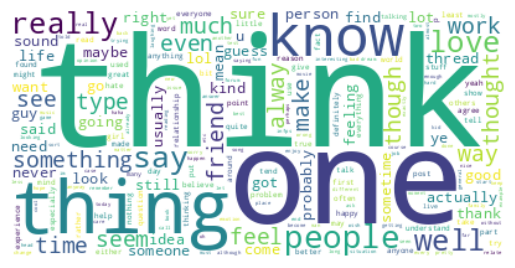

In [24]:
word_cloud_by_trait("I", 1, dataset_ie)

Extrovert Word Cloud

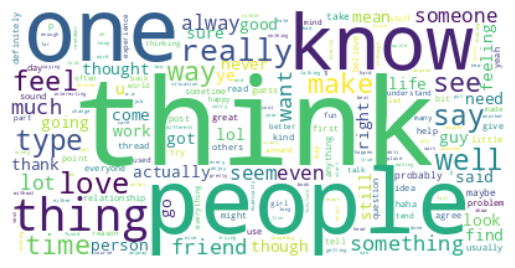

In [25]:
word_cloud_by_trait("I", 0, dataset_ie)

# Conclusion 

1. In terms of the model, we were able to handle the oversampling of data by having more examples of the less common trait.
2. However, we see that for traits like Intuitive vs. Sensing, the accuracies may have been higher because overall there were more diverse examples of Intuitive than Sensing. That led the model to classify observations as Intuitive more than Sensing. Our test set also consisted of more intuitive (N) users, leading to a higher accuracy in Intuition. 
3. The accuracies were lowest in Perceiving vs. Judging. However, we must consider that for traits like Introversion and Intuition, there are more diverse observations in our training set for those traits, so the accuracies are higher.
4. My goals next time are:
* to experiment with more advanced and complex techniques such as LSTM Neural Networks, and BERT.
* to learn how to ensure the coefficients converge for Logistic Regression
* to collect more data on Sensing and Extroversion.
* to test our models on more diverse observations of each trait.
